# Lab Assignment

## Bias, Variance, and Optimization in Polynomial Regression

**Tools:** Python, NumPy, Matplotlib  
**Restriction:** Do not use scikit-learn, `np.polyfit`, or `np.linalg.lstsq` to fit models.

### Objectives
- Implement gradient descent for polynomial regression and verify that the gradient is correct.
- See how model complexity moves a model from underfitting (high bias) to overfitting (high variance).
- Measure bias and variance from experiments instead of only describing them.
- Choose a model using validation data, not test data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

ID = 5102          # last 4 digits of student ID

rng   = np.random.default_rng(ID)
freq  = 1 + (ID % 3) * 0.5
sigma = 0.20 + (ID % 4) * 0.05

def true_f(x):                       # expects x in [0, 1]
    return np.sin(2 * np.pi * freq * x)

def make_split(n, spread=False):
    if spread:
        x = (np.arange(n) + rng.uniform(0, 1, n)) / n
    else:
        x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, sigma, n)
    return 2 * x - 1, y              # rescale to [-1, 1]

x_tr,  y_tr  = make_split(20, spread=True)
x_val, y_val = make_split(100)
x_te,  y_te  = make_split(200)

x_plot = np.linspace(-1, 1, 200)
y_true_plot = true_f((x_plot + 1) / 2)

print(f"ID = {ID}")
print(f"freq = {freq}")
print(f"sigma = {sigma:.2f}")
print(f"train/validation/test sizes = {len(x_tr)}/{len(x_val)}/{len(x_te)}")


ID = 5102
freq = 2.0
sigma = 0.30
train/validation/test sizes = 20/100/200


## Part 1: Predict Before You Run

> These answers are kept as the original predictions and are **not changed after seeing the results**, as required by the assignment.

**1. Which polynomial degree (1 to 15) do you expect to give the lowest error on unseen data for your `freq`? Why?**

i think 1, 2 or 3---- if i had to choose only 2 ,  
i dont have any reasoning just that i remeber from a teacher  
that we do  2 or 3 for more complex data

**2. Will degree 15 need more, fewer, or about the same number of gradient descent epochs as degree 3? Why?**

i think since model will get complex it might need  
more epochs due to enhanced complexity needed to be  
trained slow-ier than the less complex alternatives


## Part 2: Gradient Descent From Scratch

The model is

\[
\hat{y}=Xw
\]

where each column of \(X\) is a polynomial feature.

We use the Chebyshev-style recurrence:

\[
T_0(x)=1,\qquad T_1(x)=x
\]

and, for \(k\ge 2\),

\[
T_k(x)=2xT_{k-1}(x)-T_{k-2}(x).
\]

Each \(T_k\) is a polynomial of degree \(k\). This basis is numerically better behaved for gradient descent than raw powers \(x^k\).


In [2]:
def design_matrix(x, degree):
    """Return an (n, degree+1) matrix with columns T_0(x), ..., T_degree(x)."""
    x = np.asarray(x, dtype=float)
    X = np.empty((len(x), degree + 1), dtype=float)

    X[:, 0] = 1.0
    if degree >= 1:
        X[:, 1] = x

    for k in range(2, degree + 1):
        X[:, k] = 2.0 * x * X[:, k - 1] - X[:, k - 2]

    return X


In [3]:
def mse(X, y, w):
    """Mean squared error."""
    residual = X @ w - y
    return np.mean(residual ** 2)


In [4]:
def gradient(X, y, w):
    """Gradient of MSE with respect to w."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ w - y)


In [5]:
def gradient_descent(X, y, lr, max_epochs=20000, tol=1e-6):
    """Batch gradient descent with early stopping on gradient norm."""
    w = np.zeros(X.shape[1], dtype=float)

    for epoch in range(1, max_epochs + 1):
        grad = gradient(X, y, w)

        # Required early-stopping rule
        if np.linalg.norm(grad) < tol:
            break

        w_new = w - lr * grad

        # Small safety guard for deliberately unstable learning-rate trials
        if (not np.all(np.isfinite(w_new))) or np.linalg.norm(w_new) > 1e12:
            w = w_new
            break

        w = w_new

    return w, epoch


In [6]:
# Quick design-matrix check for degree 5
X_demo = design_matrix(x_tr, 5)
print("Shape:", X_demo.shape)
print("First 3 rows:")
print(np.round(X_demo[:3], 4))


Shape: (20, 6)
First 3 rows:
[[ 1.     -0.9005  0.6218 -0.2194 -0.2267  0.6277]
 [ 1.     -0.8907  0.5865 -0.1541 -0.312   0.7098]
 [ 1.     -0.7053 -0.0052  0.7126 -0.9999  0.6979]]


### 2a. Derivation of the gradient

The mean squared error is

\[
J(w)=\frac{1}{n}\sum_{i=1}^{n}(\hat y_i-y_i)^2
=\frac{1}{n}(Xw-y)^T(Xw-y).
\]

Let \(r=Xw-y\). Then

\[
J(w)=\frac{1}{n}r^Tr.
\]

Differentiating with respect to \(w\),

\[
\nabla_w J(w)
=\frac{1}{n}\cdot 2X^T(Xw-y).
\]

Therefore,

\[
\boxed{\nabla_w J(w)=\frac{2}{n}X^T(Xw-y)}
\]

which is exactly the expression used in `gradient()`.


In [7]:
def numerical_gradient(X, y, w, h=1e-5):
    g = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w)
        e[i] = h
        g[i] = (mse(X, y, w + e) - mse(X, y, w - e)) / (2 * h)
    return g


In [8]:
# 2b. Gradient check for degree 5 at a random w
X5 = design_matrix(x_tr, 5)
check_rng = np.random.default_rng(ID + 1)
w_check = check_rng.normal(size=X5.shape[1])

g_analytic = gradient(X5, y_tr, w_check)
g_numeric = numerical_gradient(X5, y_tr, w_check)
largest_diff = np.max(np.abs(g_analytic - g_numeric))

print("Analytic gradient :", np.round(g_analytic, 8))
print("Numerical gradient:", np.round(g_numeric, 8))
print(f"Largest absolute difference = {largest_diff:.12e}")
print("Gradient check passed:", largest_diff < 1e-6)


Analytic gradient : [-1.45287851 -0.14970041 -0.33527613  0.46383627  1.74370825  0.44301983]
Numerical gradient: [-1.45287851 -0.14970041 -0.33527613  0.46383627  1.74370825  0.44301983]
Largest absolute difference = 2.593286696495e-11
Gradient check passed: True


### 2b. Gradient-check result

The largest absolute difference between the analytic and numerical gradients is approximately **\(2.59\times10^{-11}\)**. This is far below \(10^{-6}\), so the implemented gradient passes the required check.


In [9]:
# 2c. Learning-rate experiment
learning_rates = [0.001, 0.01, 0.1, 0.5, 2.0]

def lr_trial(degree, lr, max_epochs=3000):
    X = design_matrix(x_tr, degree)
    start_loss = mse(X, y_tr, np.zeros(X.shape[1]))
    w, epochs = gradient_descent(X, y_tr, lr, max_epochs=max_epochs, tol=1e-6)
    final_loss = mse(X, y_tr, w) if np.all(np.isfinite(w)) else np.inf
    grad_norm = np.linalg.norm(gradient(X, y_tr, w)) if np.all(np.isfinite(w)) else np.inf

    if (not np.isfinite(final_loss)) or final_loss > 100 * start_loss or np.linalg.norm(w) > 1e10:
        status = "diverges"
    elif epochs < max_epochs:
        status = "converges"
    else:
        status = "very slow / epoch cap"

    return epochs, final_loss, grad_norm, status

print("Degree 3:")
print(f"{'lr':>8} {'epochs':>8} {'final MSE':>14} {'grad norm':>14}  status")
for lr in learning_rates:
    ep, loss, gn, status = lr_trial(3, lr)
    print(f"{lr:8.3f} {ep:8d} {loss:14.6f} {gn:14.6e}  {status}")

print("\nDegree 15:")
print(f"{'lr':>8} {'epochs':>8} {'final MSE':>14} {'grad norm':>14}  status")
for lr in learning_rates:
    ep, loss, gn, status = lr_trial(15, lr)
    print(f"{lr:8.3f} {ep:8d} {loss:14.6f} {gn:14.6e}  {status}")


Degree 3:
      lr   epochs      final MSE      grad norm  status
   0.001     3000       0.365540   9.855011e-02  very slow / epoch cap
   0.010     3000       0.350040   2.106610e-05  very slow / epoch cap
   0.100      393       0.350040   9.935085e-07  converges
   0.500       75       0.350040   8.754488e-07  converges
   2.000       24 6316351522239994948222976.000000   5.401307e+12  diverges

Degree 15:
      lr   epochs      final MSE      grad norm  status
   0.001     3000       0.035428   4.824888e-02  very slow / epoch cap
   0.010     3000       0.028060   9.860810e-03  very slow / epoch cap
   0.100     3000       0.021998   1.170430e-03  very slow / epoch cap
   0.500     3000       0.021894   1.204995e-04  very slow / epoch cap
   2.000       21 6534155628319968751255552.000000   5.809634e+12  diverges


### 2c. Learning-rate conclusion

For **degree 3**, learning rates `0.001` and `0.01` are very slow within 3000 epochs, `0.1` and `0.5` converge, and `2.0` diverges.

For **degree 15**, `0.001`, `0.01`, `0.1`, and `0.5` remain stable, although they do not meet the gradient-norm tolerance within 3000 epochs. `2.0` diverges.

I use **learning rate = 0.1** for the remaining experiments because it is stable for degree 15 and converges efficiently for the lower-degree models.


## Part 3: The Complexity Sweep

Train degrees 1 through 15 using the stable learning rate selected above, with `max_epochs=20000`.


In [10]:
chosen_lr = 0.1
max_epochs = 20000

results = []
weights = {}

for degree in range(1, 16):
    X_train = design_matrix(x_tr, degree)
    w, epochs = gradient_descent(
        X_train, y_tr,
        lr=chosen_lr,
        max_epochs=max_epochs,
        tol=1e-6
    )
    weights[degree] = w

    train_err = mse(X_train, y_tr, w)
    val_err = mse(design_matrix(x_val, degree), y_val, w)
    test_err = mse(design_matrix(x_te, degree), y_te, w)

    results.append({
        "degree": degree,
        "epochs": epochs,
        "train_mse": train_err,
        "val_mse": val_err,
        "test_mse": test_err,
        "w_norm": np.linalg.norm(w)
    })

val_errors = np.array([r["val_mse"] for r in results])
best_degree = int(np.argmin(val_errors) + 1)
best_result = results[best_degree - 1]

print(f"Best degree selected using validation MSE only: {best_degree}")
print(f"Validation MSE = {best_result['val_mse']:.6f}")
print(f"Test MSE (reported only after selection) = {best_result['test_mse']:.6f}")

print("\n3a. Requested table")
print(f"{'Degree':>6} {'Epochs':>8} {'Train MSE':>12} {'Val MSE':>12} {'Test MSE':>12} {'||w||_2':>12}")
for d in [1, 3, 5, 9, 15]:
    r = results[d - 1]
    print(f"{d:6d} {r['epochs']:8d} {r['train_mse']:12.6f} {r['val_mse']:12.6f} "
          f"{r['test_mse']:12.6f} {r['w_norm']:12.6f}")


Best degree selected using validation MSE only: 7
Validation MSE = 0.148930
Test MSE (reported only after selection) = 0.130314

3a. Requested table
Degree   Epochs    Train MSE      Val MSE     Test MSE      ||w||_2
     1      184     0.396731     0.582906     0.501703     0.458862
     3      393     0.350040     0.474097     0.427356     0.821618
     5      816     0.083815     0.271695     0.188575     1.142043
     9    20000     0.046407     0.160915     0.148293     1.034498
    15    20000     0.021887     0.666104     0.833418     1.792659


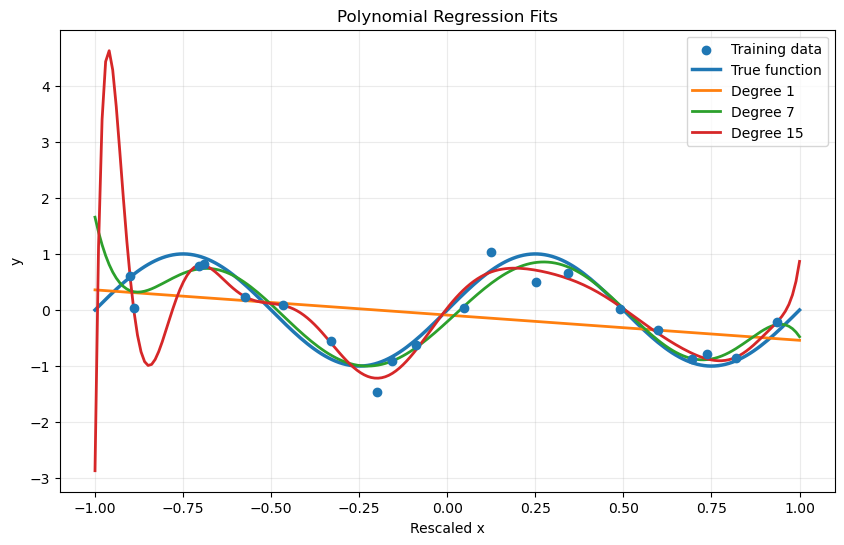

In [11]:
# 3b. Plot 1: fitted curves
plt.figure(figsize=(10, 6))
plt.scatter(x_tr, y_tr, label="Training data", zorder=3)
plt.plot(x_plot, y_true_plot, linewidth=2.5, label="True function")

for degree in [1, best_degree, 15]:
    y_fit = design_matrix(x_plot, degree) @ weights[degree]
    plt.plot(x_plot, y_fit, linewidth=2, label=f"Degree {degree}")

plt.title("Polynomial Regression Fits")
plt.xlabel("Rescaled x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


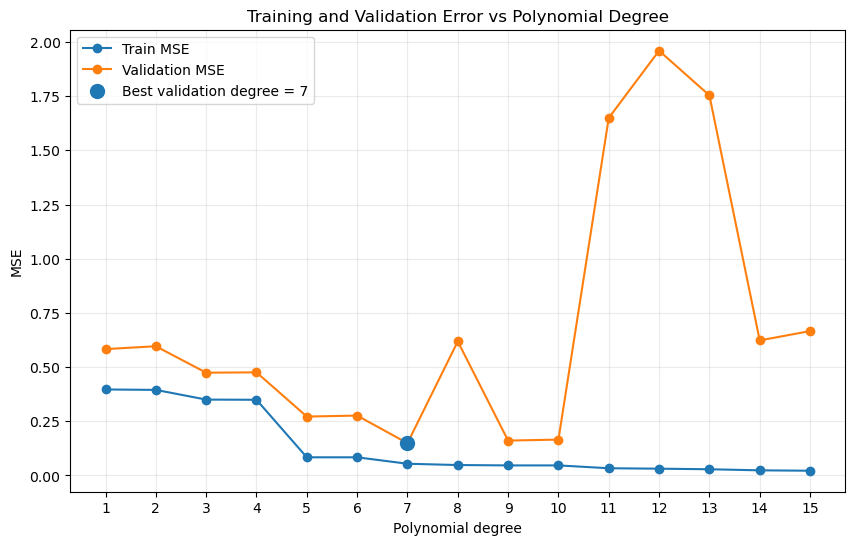

In [12]:
# 3c. Plot 2: train and validation error versus degree
degrees = np.arange(1, 16)
train_errors = np.array([r["train_mse"] for r in results])
val_errors = np.array([r["val_mse"] for r in results])

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker="o", label="Train MSE")
plt.plot(degrees, val_errors, marker="o", label="Validation MSE")
plt.scatter([best_degree], [val_errors[best_degree - 1]],
            s=100, zorder=5, label=f"Best validation degree = {best_degree}")

plt.title("Training and Validation Error vs Polynomial Degree")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.xticks(degrees)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### 3d. Questions

**1. Pick your best degree using validation MSE only, and report its test MSE. Why would picking the degree by looking at test MSE make your reported test error untrustworthy?**

The lowest validation MSE is for **degree 7** (`0.148930`), so degree 7 is selected. After making that choice, its test MSE is **`0.130314`**. If the test set were used to choose the degree, information from the test set would leak into model selection, so the final test error would no longer be an unbiased estimate of performance on genuinely unseen data.

**2. Was your Part 1 prediction right? If not, what did you misjudge?**

No. I predicted degree 2, but validation selected degree 7. I underestimated how much polynomial flexibility was needed to follow a frequency-2 sine wave; low-degree models underfit the repeated curvature.

**3. How does \(||w||_2\) change from degree 1 to degree 15, and how does that relate to the shape of the degree-15 curve?**

The weight norm rises from about **`0.4589`** at degree 1 to about **`1.7927`** at degree 15. The degree-15 fit is much more flexible and develops strong oscillations, especially close to the edges of the training region, which is consistent with larger coefficients and overfitting.

**4. Degree 15 stopped at the epoch cap, yet its training error is the lowest. What does this say about the difference between “the optimizer has stopped” and “the model generalizes”?**

The optimizer reaching the epoch cap only describes the optimization process; it does not mean the model generalizes well. Degree 15 obtains the lowest training MSE (`0.021887`) but has a much worse validation MSE (`0.666104`), showing that fitting the training data more closely can still produce poorer unseen-data performance.


## Part 4: Measuring Bias and Variance

Use five independently generated training sets. For degrees 1, 3, and 15, train one model on each set, predict on the common grid, and compute:

- **Bias²:** average over grid points of \((\text{mean prediction} - \text{true value})^2\)
- **Variance:** average over grid points of the variance of the five predictions


In [13]:
def make_train_set(seed, n=20):
    r = np.random.default_rng(seed)
    x = (np.arange(n) + r.uniform(0, 1, n)) / n
    y = true_f(x) + r.normal(0, sigma, n)
    return 2 * x - 1, y

seeds = [ID * 100 + k for k in range(5)]
x_grid = np.linspace(-1, 1, 100)
true_grid = true_f((x_grid + 1) / 2)


In [14]:
bias_variance_results = {}
all_predictions = {}

for degree in [1, 3, 15]:
    predictions = []

    for seed in seeds:
        x_i, y_i = make_train_set(seed)
        X_i = design_matrix(x_i, degree)
        w_i, _ = gradient_descent(
            X_i, y_i,
            lr=chosen_lr,
            max_epochs=max_epochs,
            tol=1e-6
        )

        pred_i = design_matrix(x_grid, degree) @ w_i
        predictions.append(pred_i)

    predictions = np.asarray(predictions)
    mean_prediction = predictions.mean(axis=0)

    bias_sq = np.mean((mean_prediction - true_grid) ** 2)
    variance = np.mean(np.var(predictions, axis=0))

    bias_variance_results[degree] = {
        "bias_sq": bias_sq,
        "variance": variance,
        "mean_prediction": mean_prediction
    }
    all_predictions[degree] = predictions

print("4a. Bias-variance table")
print(f"{'Degree':>6} {'Bias^2':>14} {'Variance':>14}")
for degree in [1, 3, 15]:
    r = bias_variance_results[degree]
    print(f"{degree:6d} {r['bias_sq']:14.6f} {r['variance']:14.6f}")


4a. Bias-variance table
Degree         Bias^2       Variance
     1       0.424612       0.002853
     3       0.377265       0.018439
    15       0.150476       0.313430


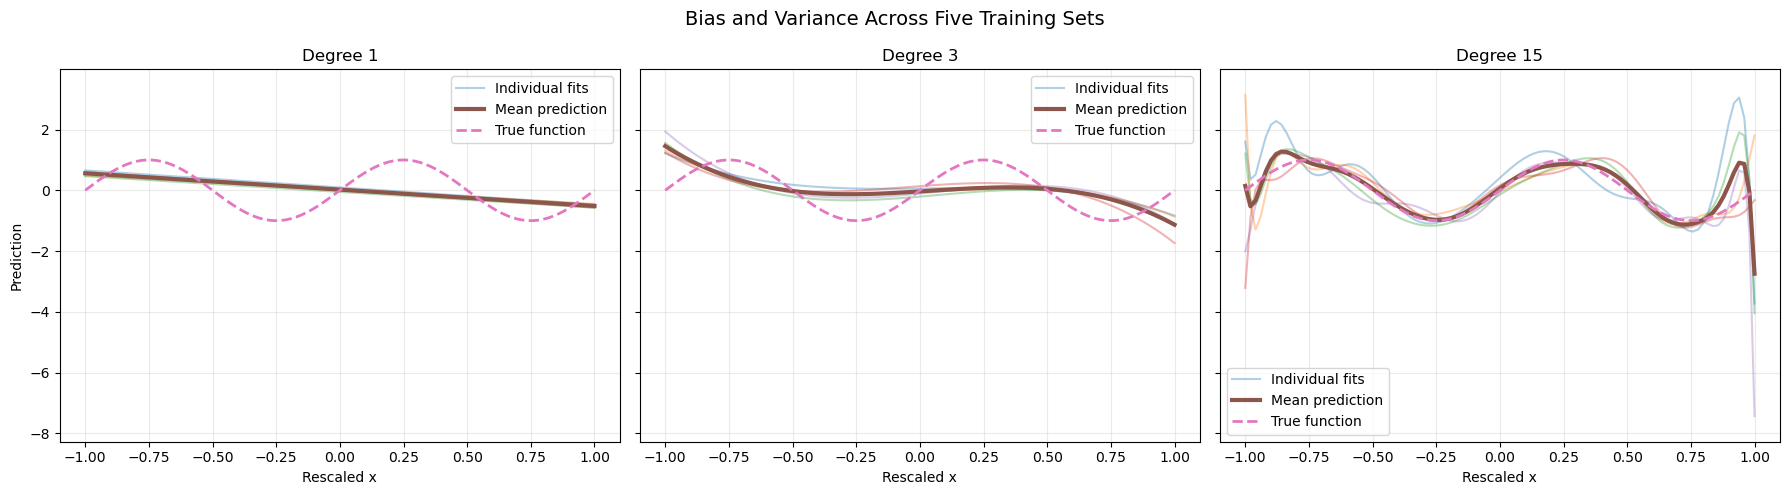

In [15]:
# 4b. Plot 3: five fits, mean fit, and true function
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Common y-limits across all panels
all_y = [true_grid]
for degree in [1, 3, 15]:
    all_y.extend(list(all_predictions[degree]))
all_y = np.concatenate(all_y)
pad = 0.08 * (all_y.max() - all_y.min())
common_ylim = (all_y.min() - pad, all_y.max() + pad)

for ax, degree in zip(axes, [1, 3, 15]):
    preds = all_predictions[degree]
    mean_pred = bias_variance_results[degree]["mean_prediction"]

    for i, curve in enumerate(preds):
        ax.plot(x_grid, curve, alpha=0.35,
                label="Individual fits" if i == 0 else None)

    ax.plot(x_grid, mean_pred, linewidth=3, label="Mean prediction")
    ax.plot(x_grid, true_grid, linestyle="--", linewidth=2, label="True function")

    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("Rescaled x")
    ax.set_ylim(common_ylim)
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Prediction")
fig.suptitle("Bias and Variance Across Five Training Sets", fontsize=14)
plt.tight_layout()
plt.show()


### 4c. Questions

**1. Which degree has the largest Bias² and which has the largest variance? Point to what you see in Plot 3.**

Degree **1** has the largest Bias² (**`0.424612`**), while degree **15** has the largest variance (**`0.313430`**). In Plot 3, the degree-1 curves stay similarly shaped but systematically miss the true oscillating function, whereas the degree-15 curves spread apart much more from one training set to another, especially near the boundaries.

**2. How does this table explain the shape of your validation-error curve in Plot 2?**

At low degree, error is high because the model has high bias and underfits. As degree increases, bias falls and validation error improves, but at very high degree the variance becomes large; that instability makes validation error rise again, producing the usual bias-variance trade-off.


## Part 5: Debugging

A classmate wrote:

```python
def gradient(X, y, w):
    n = len(y)
    return (2 / n) * X.T @ (y - X @ w)
```

**1. Identify the bug and explain, using the update rule \(w \leftarrow w-lr\cdot grad\), why it makes the loss increase.**

The residual has the wrong sign. The correct MSE gradient is

frac{2}{n}X^T(Xw-y),

but the classmate computes

frac{2}{n}X^T(y-Xw),

which is exactly the **negative** of the correct gradient. Therefore the update

w-leftarrow w-lr\cdot grad

moves in the direction of the true positive gradient instead of the negative gradient. It performs gradient **ascent**, so the loss tends to increase.

**2. Would the gradient check from Part 2b have caught it? What would it have reported?**

Yes. The numerical gradient estimates the derivative of the MSE itself, so it would agree with the correctly signed analytic gradient and disagree strongly with the classmate's sign-reversed version. For the same degree-5 check point used above, the maximum absolute difference would be about **`3.49`**, which is enormously larger than the allowed `1e-6`.
